# BPMA probability heat map

Run the final cell to fit and plot every supported 2D dataset.

In [1]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message="A worker stopped while some jobs were given to the executor.*",
    category=UserWarning,
)

project_root = Path.cwd()
if not (project_root / "bayesian_predictive_model_averaging").is_dir() and (project_root.parent / "bayesian_predictive_model_averaging").is_dir():
    project_root = project_root.parent
if (project_root / "bayesian_predictive_model_averaging").is_dir():
    sys.path.insert(0, str(project_root))

from scripts.classification_2d_demo import run_and_report
from IPython.display import display
import matplotlib.pyplot as plt

import numpy as np
from typing import Any

def plot_probability_heatmap(
    model: Any,
    X: np.ndarray,
    y: np.ndarray | None = None,
    *,
    X_train: np.ndarray | None = None,
    y_train: np.ndarray | None = None,
    padding: float = 0.55,
    grid_size: int = 250,
    title: str | None = None,
    ax: Any | None = None,
    colorbar: bool = True,
    decision_margin: float = 0.1,
):
    """Plot binary or multiclass probabilities over a 2D feature grid.

    Multiclass backgrounds use a probability-weighted ``tab10`` color mixture.
    Normalized entropy fades uncertain regions toward white, while black
    contours show predicted-class boundaries and the confidence boundary.
    The thin contour is controlled by ``decision_margin``. For binary plots it
    shows ``abs(p_1 - p_0) == decision_margin``; for multiclass plots it shows
    where the top-class probability exceeds the second-highest probability by
    ``decision_margin``. This makes the contour comparable across class counts.
    Matplotlib is imported lazily so plotting remains an optional dependency.
    """

    import matplotlib.pyplot as plt
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    X = np.asarray(X)
    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError("X must have shape (n_samples, 2) for heatmap plotting")
    if grid_size < 2:
        raise ValueError("grid_size must be at least 2")
    if not np.isfinite(decision_margin) or not 0.0 <= decision_margin <= 1.0:
        raise ValueError("decision_margin must be finite and between 0 and 1")
    X_points = X if X_train is None else np.asarray(X_train)
    y_points = y if y_train is None else np.asarray(y_train)
    if y_points is None:
        raise ValueError("y or y_train is required to plot data points")

    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - padding, X[:, 0].max() + padding, grid_size),
        np.linspace(X[:, 1].min() - padding, X[:, 1].max() + padding, grid_size),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    probabilities = np.asarray(model.predict_proba(grid), dtype=float).reshape(
        xx.shape + (len(model.classes_),)
    )
    classes = np.asarray(model.classes_)
    cmap = plt.get_cmap("tab10")
    palette = np.asarray([cmap(index % 10)[:3] for index in range(len(classes))])
    predicted_indices = np.argmax(probabilities, axis=2)

    if len(classes) > 2:
        color_mixture = probabilities @ palette
        safe_probabilities = np.clip(probabilities, np.finfo(float).tiny, 1.0)
        entropy = -np.sum(probabilities * np.log(safe_probabilities), axis=2)
        confidence = 1.0 - entropy / np.log(len(classes))
        rgb = 1.0 - confidence[..., None] * (1.0 - color_mixture)
        if ax is None:
            fig, axis = plt.subplots(figsize=(9, 6.5))
        else:
            axis = ax
            fig = axis.figure
        axis.imshow(
            np.clip(rgb, 0.0, 1.0),
            origin="lower",
            extent=(xx.min(), xx.max(), yy.min(), yy.max()),
            interpolation="nearest",
            aspect="equal",
        )
        boundaries = np.arange(0.5, len(classes) - 0.5, 1.0)
        axis.contour(xx, yy, predicted_indices, levels=boundaries,
                     linewidths=2, colors="black")
        sorted_probabilities = np.sort(probabilities, axis=2)
        decision_margin_surface = sorted_probabilities[:, :, -1] - sorted_probabilities[:, :, -2]
        if decision_margin_surface.min() <= decision_margin <= decision_margin_surface.max():
            axis.contour(xx, yy, decision_margin_surface, levels=[decision_margin], linewidths=0.45,
                         colors="black")
        if colorbar:
            confidence_scale = ScalarMappable(norm=Normalize(0.0, 1.0), cmap="Greys_r")
            confidence_scale.set_array(confidence)
            confidence_bar = fig.colorbar(confidence_scale, ax=axis)
            confidence_bar.set_label("Confidence (1 − normalized entropy)")
    else:
        if ax is None:
            fig, axis = plt.subplots(figsize=(9, 6.5))
        else:
            axis = ax
            fig = axis.figure
        probability = probabilities[:, :, 1]
        axis.contourf(xx, yy, probability, levels=np.linspace(0, 1, 41),
                      cmap="RdBu_r", vmin=0, vmax=1, alpha=0.9)
        axis.contour(xx, yy, probability, levels=[0.5], linewidths=2.0,
                     colors="black")
        decision_margin_surface = np.abs(2.0 * probability - 1.0)
        if (
            decision_margin_surface.min()
            <= decision_margin
            <= decision_margin_surface.max()
        ):
            axis.contour(xx, yy, decision_margin_surface, levels=[decision_margin], linewidths=0.45,
                         colors="black")

    for class_index, class_value in enumerate(classes):
        mask = y_points == class_value
        axis.scatter(
            X_points[mask, 0], X_points[mask, 1], s=24,
            color=palette[class_index], edgecolors="white", linewidths=0.45,
            label=f"Class {class_value}",
        )
    axis.set_title(title or "Class probability heatmap")
    axis.set_xlabel("Feature 1")
    axis.set_ylabel("Feature 2")
    axis.set_aspect("equal", adjustable="box")
    axis.legend(loc="upper right")
    if ax is None:
        fig.tight_layout()
    return fig


In [2]:
DATASETS = (
    "circles",
    "moon",
    "spirals",
    "xor",
    "checkerboard",
    "gaussian",
    "blobs",
    "anisotropic_blobs",
    "classification",
)
BLOB_CENTER_RADIUS = 3.0
BLOB_CLUSTER_STANDARD_DEVIATION = 1.5

DATA_PARAMETERS = {
    "n_samples": 2000,
    "noise": 0.24,
    "random_state": 71,
    "feature_indices": (0, 1),
    "mean_distance": 3.0,
    "standard_deviation": 1.0,
    "n_classes": 4,
    "blob_center_radius": BLOB_CENTER_RADIUS,
    "blob_cluster_standard_deviation": BLOB_CLUSTER_STANDARD_DEVIATION,
    "circle_factor": 0.5,
    "spiral_turns": 2,
    "spiral_noise": 0.03,
    "checkerboard_cells": 4,
    "checkerboard_extent": 4.0,
    "checkerboard_label_noise": 0.0,
    "anisotropy": 3.0,
    "rotation": 0.35,
    "classification_class_sep": 1.0,
    "classification_flip_y": 0.05,
}

SPLIT_PARAMETERS = {
    "test_size": 0.30,
    "split_random_state": 7,
}

ESTIMATORS_PER_FAMILY = 100
ADAPTIVE_ROUND_SIZE_PER_FAMILY = 10

MODEL_PARAMETERS = {
    "temperature": 0.1,
    "n_estimators": "auto",
    "max_estimators": ESTIMATORS_PER_FAMILY,
    "tolerance": 0.001,
    "convergence_metric": "median",
    "convergence_size": 256,
    "cv": 5,
    "n_jobs": -1,
    "random_state": 12,
}

PLOT_PARAMETERS = {
    "padding": 0.55,
    "grid_size": 150,
    "decision_margin": 0.1,
}



RANDOM_FOREST ONLY
dataset: circles
runtime: 39.50s
test accuracy: 0.815
test errors: 111/600
test error: 0.185; Bayes error (generator oracle): 0.172; model/Bayes error ratio: 1.08
estimators used: 100
converged: False
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.629, 200=0.206, 400=0.165
  random-forest max-depth posterior shares: 4=0.455, None=0.331, 6=0.180, 8=0.034
  random-forest criterion posterior shares: gini=0.529, entropy=0.471
20 estimators: initial ensemble
40 estimators: median probability change = 0.013197
80 estimators: median probability change = 0.006949
100 estimators: median

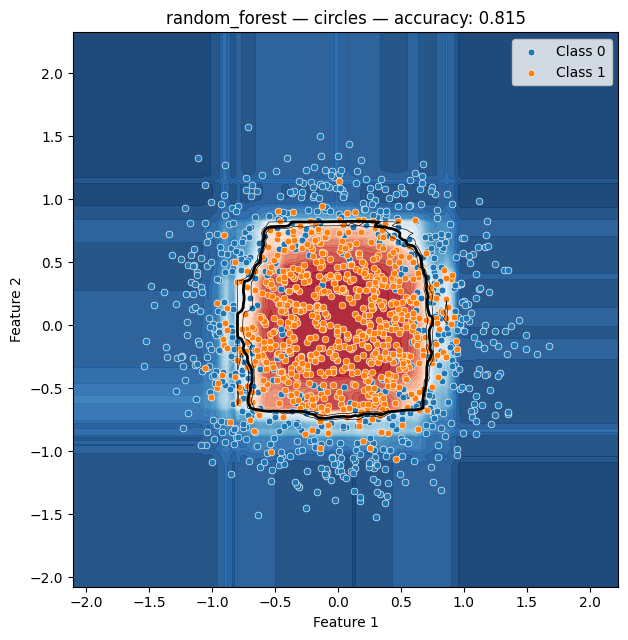

dataset: moon
runtime: 37.54s
test accuracy: 0.928
test errors: 43/600
test error: 0.072; Bayes error (generator oracle): 0.066; model/Bayes error ratio: 1.09
estimators used: 100
converged: False
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.637, 200=0.199, 400=0.164
  random-forest max-depth posterior shares: 4=0.417, None=0.357, 6=0.191, 8=0.035
  random-forest criterion posterior shares: gini=0.520, entropy=0.480
20 estimators: initial ensemble
40 estimators: median probability change = 0.007548
80 estimators: median probability change = 0.004423
100 estimators: median probability change = 0.

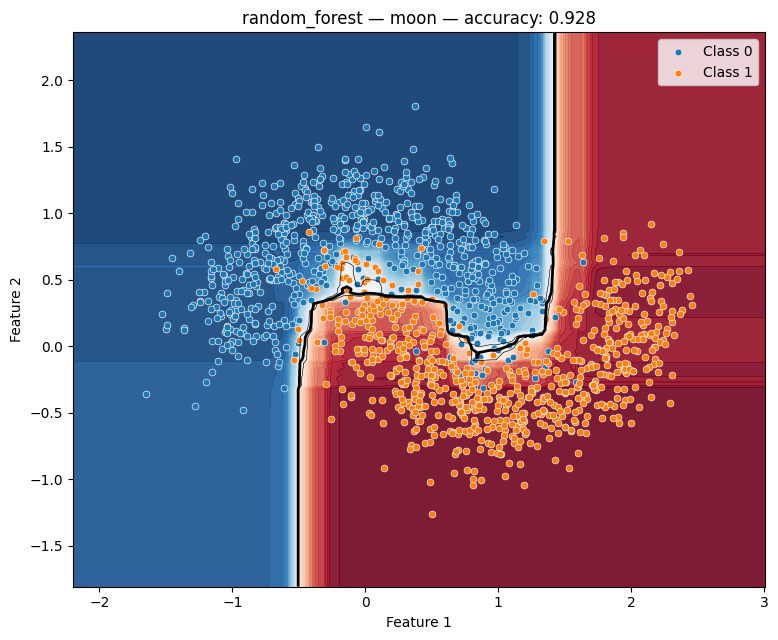

dataset: spirals
runtime: 37.47s
test accuracy: 0.978
test errors: 13/600
test error: 0.022; Bayes error (generator oracle): 0.000; model/Bayes error ratio: infinite
estimators used: 100
converged: False
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.632, 200=0.245, 400=0.122
  random-forest max-depth posterior shares: None=0.688, 4=0.188, 6=0.096, 8=0.028
  random-forest criterion posterior shares: gini=0.554, entropy=0.446
20 estimators: initial ensemble
40 estimators: median probability change = 0.035791
80 estimators: median probability change = 0.031826
100 estimators: median probability chan

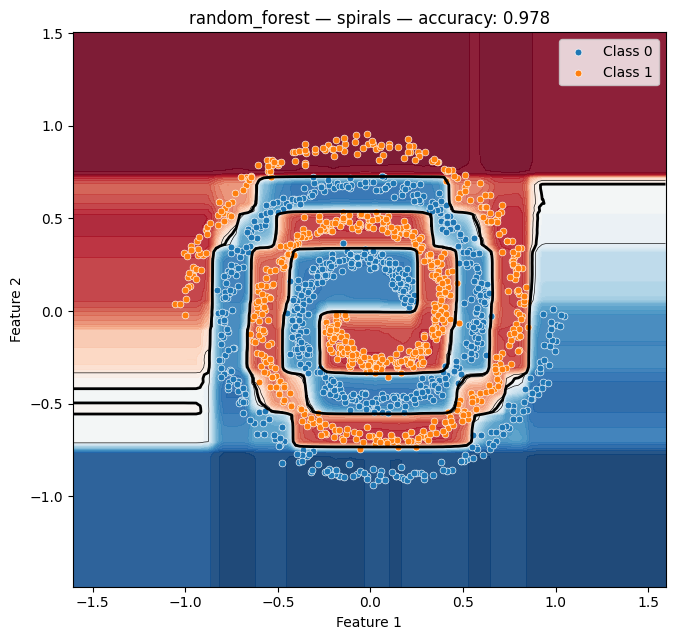

dataset: xor
runtime: 41.07s
test accuracy: 0.825
test errors: 105/600
test error: 0.175; Bayes error (density estimate): 0.166; model/Bayes error ratio: 1.05
estimators used: 100
converged: False
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.622, 200=0.207, 400=0.171
  random-forest max-depth posterior shares: 4=0.430, None=0.355, 6=0.180, 8=0.035
  random-forest criterion posterior shares: gini=0.542, entropy=0.458
20 estimators: initial ensemble
40 estimators: median probability change = 0.015342
80 estimators: median probability change = 0.006947
100 estimators: median probability change = 0.

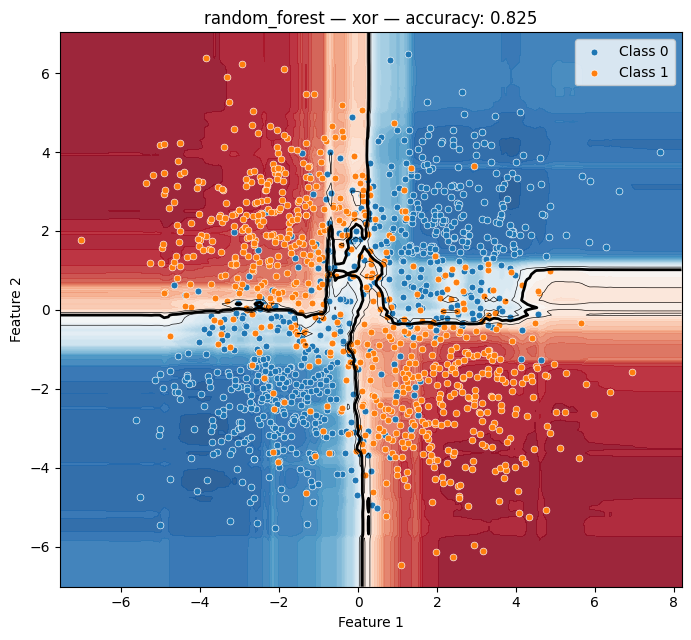

dataset: checkerboard
runtime: 54.35s
test accuracy: 0.988
test errors: 7/600
test error: 0.012; Bayes error (generator oracle): 0.000; model/Bayes error ratio: infinite
estimators used: 100
converged: False
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.633, 200=0.236, 400=0.131
  random-forest max-depth posterior shares: None=0.661, 4=0.183, 6=0.126, 8=0.030
  random-forest criterion posterior shares: gini=0.564, entropy=0.436
20 estimators: initial ensemble
40 estimators: median probability change = 0.034081
80 estimators: median probability change = 0.025784
100 estimators: median probability 

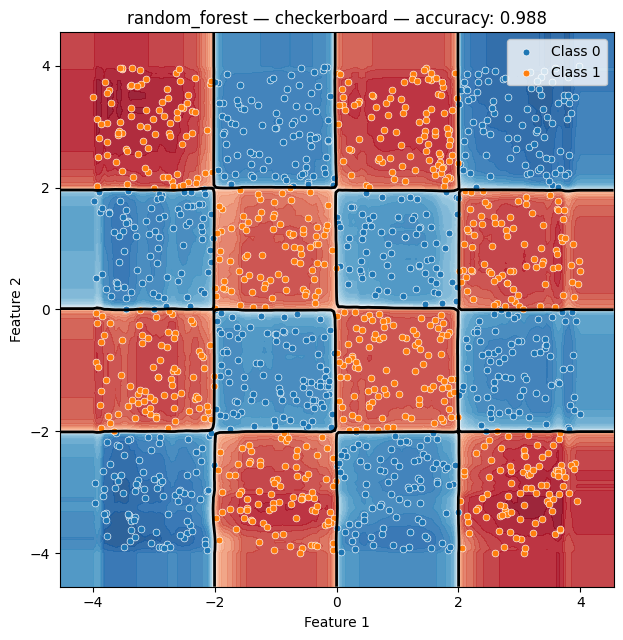

dataset: gaussian
runtime: 60.87s
test accuracy: 0.955
test errors: 27/600
test error: 0.045; Bayes error (exact): 0.067; model/Bayes error ratio: 0.67
estimators used: 100
converged: True
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.629, 200=0.203, 400=0.168
  random-forest max-depth posterior shares: 4=0.501, None=0.301, 6=0.168, 8=0.030
  random-forest criterion posterior shares: gini=0.514, entropy=0.486
20 estimators: initial ensemble
40 estimators: median probability change = 0.001331
80 estimators: median probability change = 0.001968
100 estimators: median probability change = 0.000528


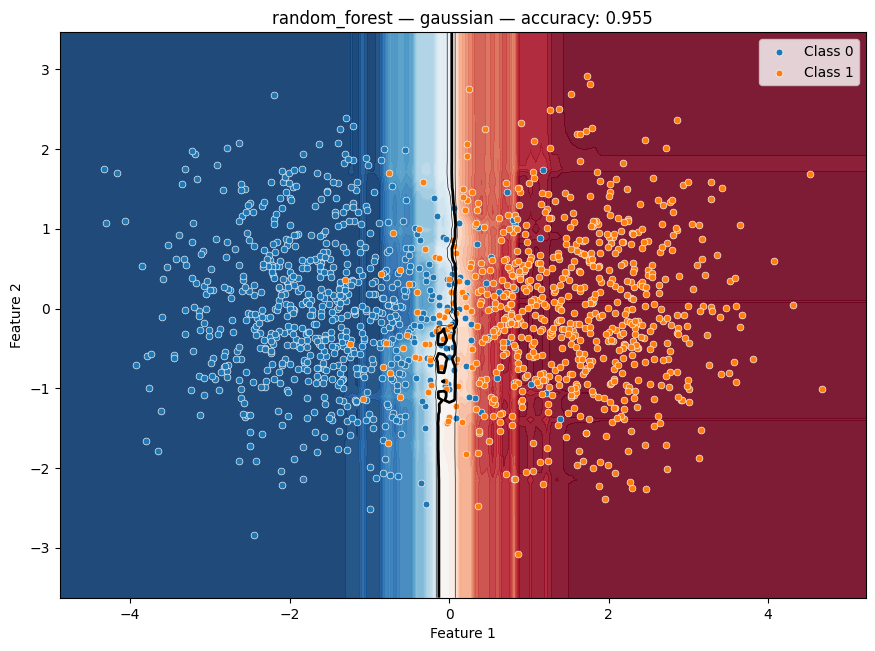

dataset: blobs
runtime: 86.00s
test accuracy: 0.835
test errors: 99/600
test error: 0.165; Bayes error (density estimate): 0.155; model/Bayes error ratio: 1.06
estimators used: 100
converged: True
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.595, 200=0.280, 400=0.126
  random-forest max-depth posterior shares: 4=0.460, None=0.395, 6=0.089, 8=0.056
  random-forest criterion posterior shares: entropy=0.574, gini=0.426
20 estimators: initial ensemble
40 estimators: median probability change = 0.003180
80 estimators: median probability change = 0.001774
100 estimators: median probability change = 0.

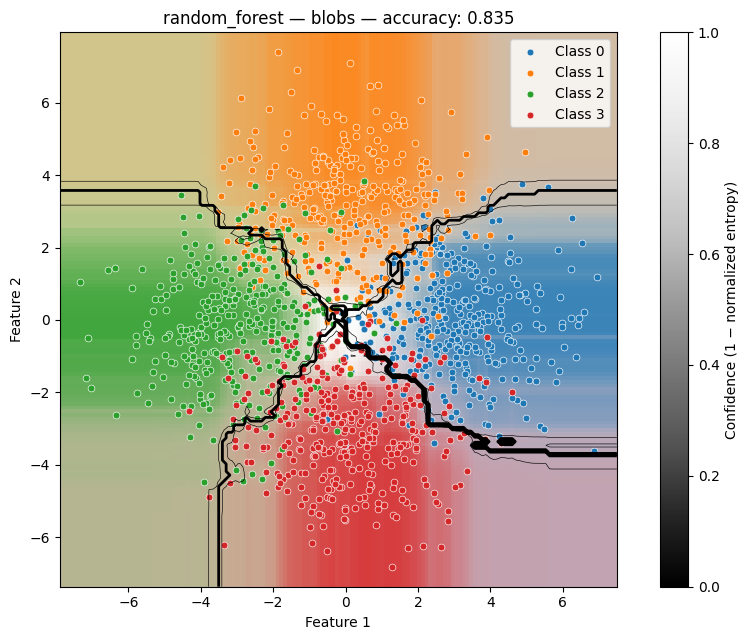

dataset: anisotropic_blobs
runtime: 72.21s
test accuracy: 0.830
test errors: 102/600
test error: 0.170; Bayes error (density estimate): 0.155; model/Bayes error ratio: 1.09
estimators used: 100
converged: True
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.594, 200=0.272, 400=0.134
  random-forest max-depth posterior shares: 4=0.469, None=0.387, 6=0.088, 8=0.056
  random-forest criterion posterior shares: entropy=0.572, gini=0.428
20 estimators: initial ensemble
40 estimators: median probability change = 0.003907
80 estimators: median probability change = 0.002167
100 estimators: median probabilit

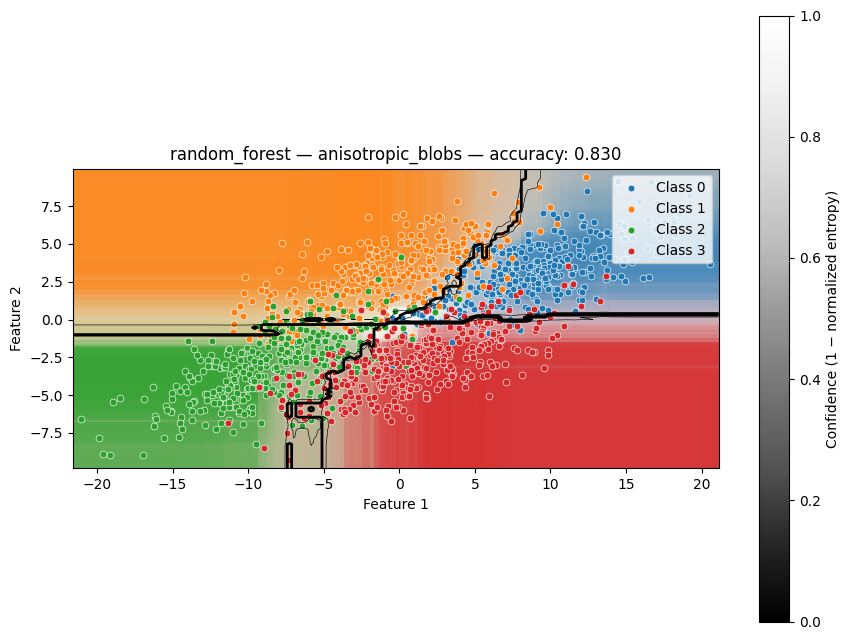

dataset: classification
runtime: 76.76s
test accuracy: 0.872
test errors: 77/600
test error: 0.128; Bayes error: unavailable
estimators used: 100
converged: True
family posterior shares: random_forest=1.000
  gaussian-mixture covariance structure posterior shares: unavailable
  gaussian-mixture component-count posterior shares (top 12): unavailable
  knn k posterior shares (top 12): unavailable
  linear-mixture expert-count posterior shares: unavailable
  mlp architecture posterior shares: unavailable
  mlp activation posterior shares: unavailable
  random-forest tree-count posterior shares: 100=0.608, 200=0.268, 400=0.125
  random-forest max-depth posterior shares: None=0.442, 4=0.400, 6=0.092, 8=0.065
  random-forest criterion posterior shares: entropy=0.558, gini=0.442
20 estimators: initial ensemble
40 estimators: median probability change = 0.003465
80 estimators: median probability change = 0.002651
100 estimators: median probability change = 0.000847


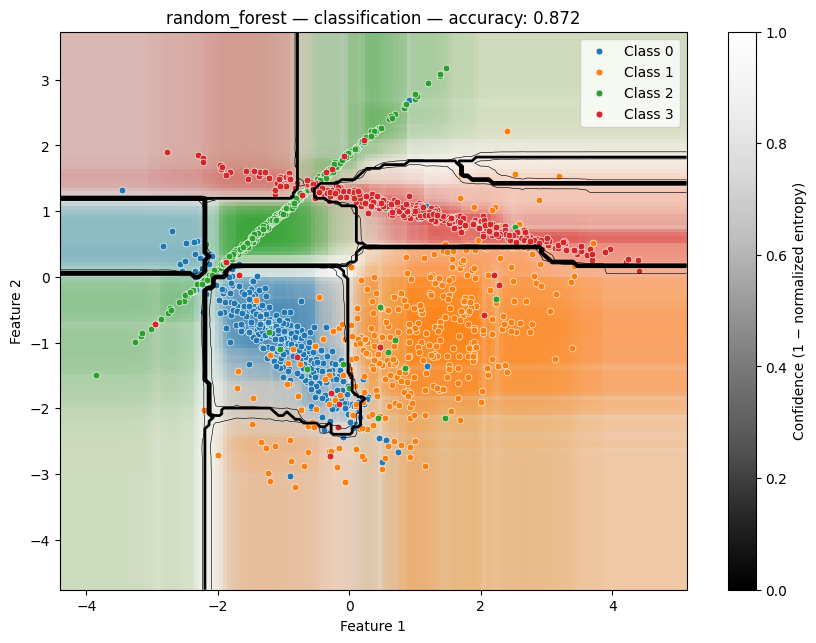

In [3]:
from bayesian_predictive_model_averaging import (
    RandomForestAdapter,
    FamilyRegistration,
    GaussianMixtureAdapter,
    KNNAdapter,
    LinearMixtureAdapter,
    MLPAdapter,
)

FAMILY_ADAPTERS = (
    ("random_forest", RandomForestAdapter),
#    ("linear_mixture", LinearMixtureAdapter),
#    ("gaussian_mixture", GaussianMixtureAdapter),
#    ("knn", KNNAdapter),
#    ("mlp", MLPAdapter),
)

for family_name, adapter_class in FAMILY_ADAPTERS:
    print(f"\n{'=' * 72}\n{family_name.upper()} ONLY\n{'=' * 72}")
    family_model_parameters = {
        **MODEL_PARAMETERS,
        "family_registry": [FamilyRegistration(adapter_class(), 1.0)],
    }
    for result in run_and_report(
        DATASETS,
        dataset_parameters=DATA_PARAMETERS,
        split_parameters=SPLIT_PARAMETERS,
        model_parameters=family_model_parameters,
    ):
        figure = plot_probability_heatmap(
            result.model,
            result.X,
            result.y,
            X_train=result.X_train,
            y_train=result.y_train,
            title=f"{family_name} — {result.dataset} — accuracy: {result.test_accuracy:.3f}",
            **PLOT_PARAMETERS,
        )
        display(figure)
        plt.close(figure)

dataset: circles
runtime: 32.90s
test accuracy: 0.808
test errors: 115/600
test error: 0.192; Bayes error (generator oracle): 0.172; model/Bayes error ratio: 1.12
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.324, knn=0.183, linear_mixture=0.093, mlp=0.158, random_forest=0.242
  gaussian-mixture covariance structure posterior shares: isotropic=0.527, diagonal=0.245, full=0.229
  gaussian-mixture component-count posterior shares (top 12): 2=0.150, 8=0.115, 14=0.109, 1=0.097, 4=0.095, 24=0.077, 5=0.073, 28=0.063, 23=0.038, 15=0.037, 22=0.037, 7=0.037, other=0.072
  knn k posterior shares (top 12): 46=0.082, 59=0.079, 29=0.066, 23=0.065, 161=0.060, 51=0.059, 44=0.049, 197=0.043, 368=0.042, 14=0.042, 158=0.041, 369=0.039, other=0.335
  linear-mixture expert-count posterior shares: 5=0.362, 1=0.283, 3=0.139, 2=0.116, 4=0.100
  mlp architecture posterior shares: (16,)=0.567, (32,)=0.160, (32, 16)=0.146, (64,)=0.127
  mlp activation posterior shares: relu=0

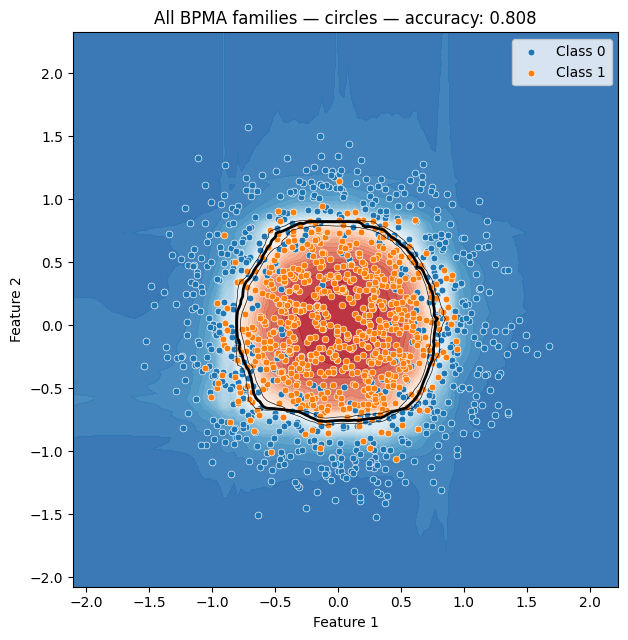

dataset: moon
runtime: 45.75s
test accuracy: 0.930
test errors: 42/600
test error: 0.070; Bayes error (generator oracle): 0.066; model/Bayes error ratio: 1.06
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.350, knn=0.168, linear_mixture=0.141, mlp=0.136, random_forest=0.205
  gaussian-mixture covariance structure posterior shares: isotropic=0.533, full=0.255, diagonal=0.213
  gaussian-mixture component-count posterior shares (top 12): 2=0.192, 8=0.127, 4=0.093, 14=0.089, 1=0.068, 5=0.064, 24=0.061, 28=0.057, 23=0.034, 22=0.032, 13=0.032, 6=0.031, other=0.119
  knn k posterior shares (top 12): 29=0.095, 59=0.094, 46=0.090, 44=0.082, 161=0.078, 23=0.075, 368=0.046, 14=0.045, 369=0.043, 428=0.043, 158=0.042, 115=0.036, other=0.231
  linear-mixture expert-count posterior shares: 1=0.454, 5=0.251, 2=0.145, 3=0.081, 4=0.070
  mlp architecture posterior shares: (16,)=0.581, (32, 16)=0.186, (32,)=0.162, (64,)=0.070
  mlp activation posterior shares: logistic=

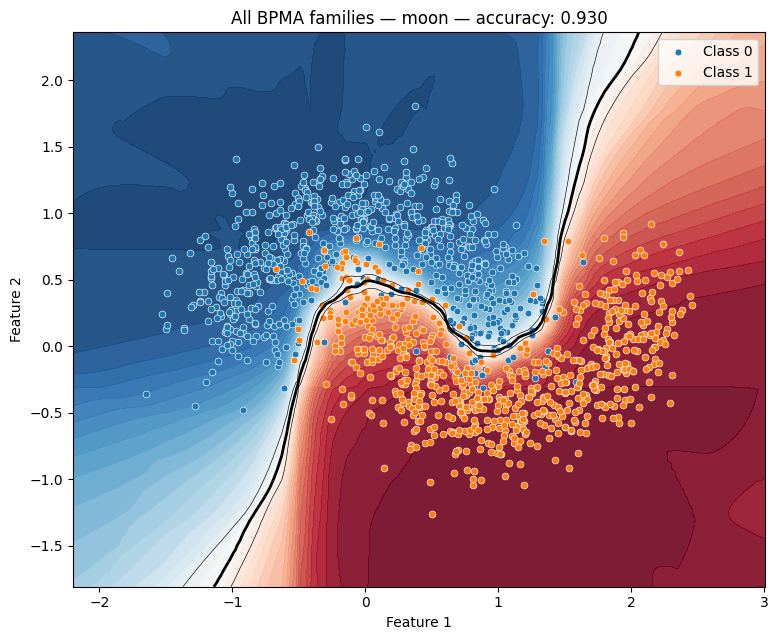

dataset: spirals
runtime: 39.36s
test accuracy: 0.998
test errors: 1/600
test error: 0.002; Bayes error (generator oracle): 0.000; model/Bayes error ratio: infinite
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.415, knn=0.193, linear_mixture=0.072, mlp=0.052, random_forest=0.269
  gaussian-mixture covariance structure posterior shares: isotropic=0.559, full=0.334, diagonal=0.107
  gaussian-mixture component-count posterior shares (top 12): 28=0.236, 14=0.170, 8=0.081, 24=0.073, 23=0.067, 22=0.066, 10=0.059, 2=0.058, 1=0.033, 15=0.030, 7=0.027, 4=0.023, other=0.076
  knn k posterior shares (top 12): 59=0.088, 44=0.085, 46=0.075, 29=0.058, 161=0.045, 122=0.042, 51=0.040, 23=0.037, 344=0.036, 368=0.035, 158=0.033, 428=0.033, other=0.393
  linear-mixture expert-count posterior shares: 1=0.456, 5=0.268, 3=0.185, 2=0.092
  mlp architecture posterior shares: (16,)=0.735, (32,)=0.136, (32, 16)=0.129
  mlp activation posterior shares: logistic=0.529, tanh=0.2

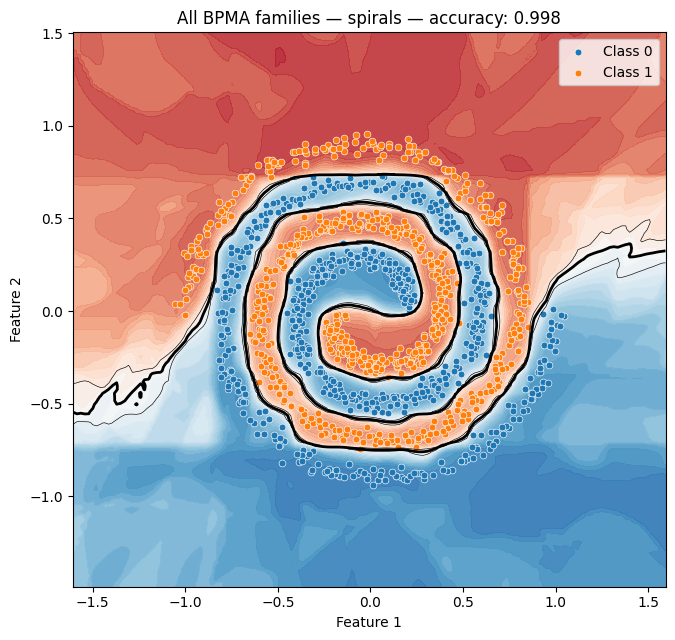

dataset: xor
runtime: 36.97s
test accuracy: 0.837
test errors: 98/600
test error: 0.163; Bayes error (density estimate): 0.166; model/Bayes error ratio: 0.98
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.307, knn=0.166, linear_mixture=0.122, mlp=0.212, random_forest=0.193
  gaussian-mixture covariance structure posterior shares: isotropic=0.536, diagonal=0.258, full=0.206
  gaussian-mixture component-count posterior shares (top 12): 2=0.221, 8=0.113, 4=0.112, 14=0.103, 24=0.075, 5=0.074, 1=0.063, 10=0.041, 15=0.037, 23=0.037, 22=0.036, 11=0.034, other=0.053
  knn k posterior shares (top 12): 46=0.088, 59=0.087, 161=0.075, 29=0.073, 23=0.073, 44=0.064, 14=0.061, 368=0.048, 369=0.045, 428=0.043, 115=0.041, 158=0.040, other=0.263
  linear-mixture expert-count posterior shares: 5=0.471, 1=0.227, 3=0.122, 2=0.098, 4=0.081
  mlp architecture posterior shares: (16,)=0.441, (32,)=0.249, (32, 16)=0.200, (64,)=0.111
  mlp activation posterior shares: logistic=

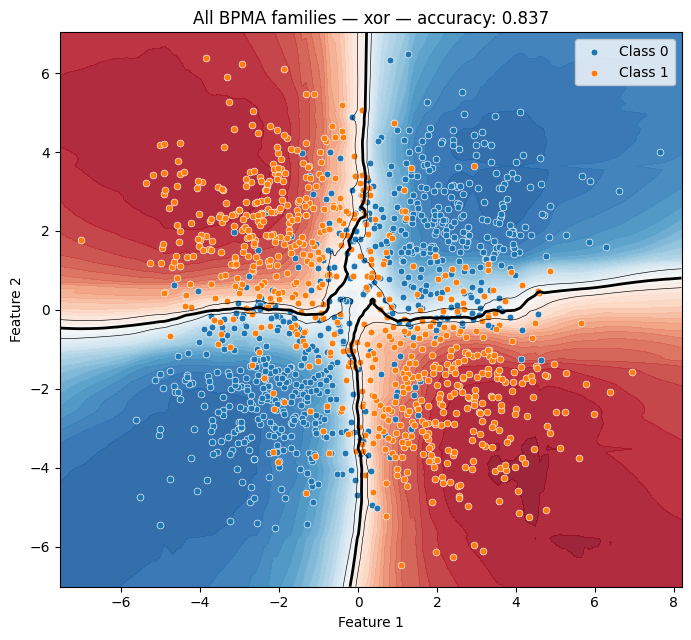

dataset: checkerboard
runtime: 39.57s
test accuracy: 0.980
test errors: 12/600
test error: 0.020; Bayes error (generator oracle): 0.000; model/Bayes error ratio: infinite
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.367, knn=0.171, linear_mixture=0.069, mlp=0.126, random_forest=0.268
  gaussian-mixture covariance structure posterior shares: isotropic=0.526, full=0.292, diagonal=0.182
  gaussian-mixture component-count posterior shares (top 12): 28=0.139, 14=0.122, 8=0.121, 24=0.110, 2=0.057, 11=0.049, 23=0.049, 15=0.048, 10=0.048, 22=0.048, 13=0.044, 1=0.039, other=0.126
  knn k posterior shares (top 12): 59=0.106, 46=0.101, 29=0.082, 161=0.049, 44=0.044, 23=0.041, 51=0.041, 197=0.039, 428=0.039, 368=0.039, 369=0.039, 115=0.037, other=0.342
  linear-mixture expert-count posterior shares: 1=0.403, 5=0.201, 2=0.195, 3=0.103, 4=0.098
  mlp architecture posterior shares: (16,)=0.520, (32, 16)=0.284, (32,)=0.196
  mlp activation posterior shares: logisti

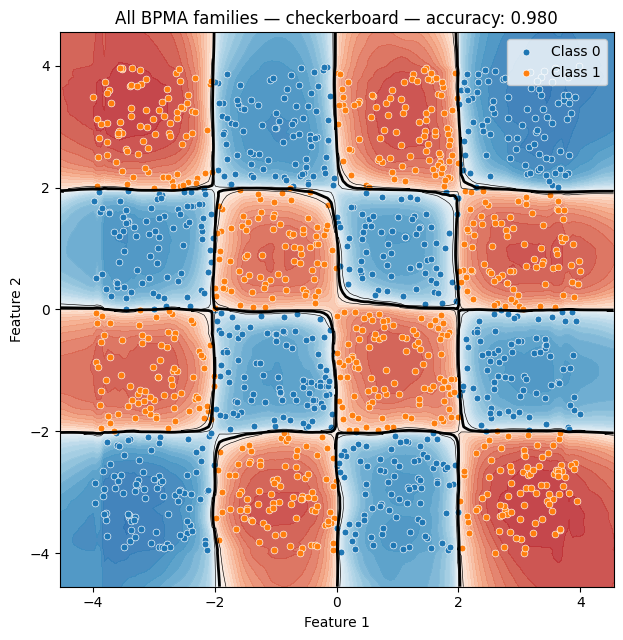

dataset: gaussian
runtime: 39.02s
test accuracy: 0.952
test errors: 29/600
test error: 0.048; Bayes error (exact): 0.067; model/Bayes error ratio: 0.72
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.309, knn=0.164, linear_mixture=0.180, mlp=0.152, random_forest=0.196
  gaussian-mixture covariance structure posterior shares: isotropic=0.558, full=0.261, diagonal=0.181
  gaussian-mixture component-count posterior shares (top 12): 2=0.237, 1=0.147, 4=0.093, 8=0.086, 14=0.083, 28=0.062, 5=0.055, 13=0.032, 23=0.031, 6=0.030, 7=0.030, 10=0.030, other=0.084
  knn k posterior shares (top 12): 44=0.076, 59=0.070, 29=0.069, 46=0.068, 161=0.067, 368=0.057, 428=0.057, 23=0.056, 115=0.055, 369=0.054, 158=0.053, 207=0.051, other=0.265
  linear-mixture expert-count posterior shares: 1=0.383, 5=0.256, 3=0.178, 2=0.132, 4=0.051
  mlp architecture posterior shares: (16,)=0.577, (32,)=0.166, (32, 16)=0.147, (64,)=0.111
  mlp activation posterior shares: logistic=0.430, 

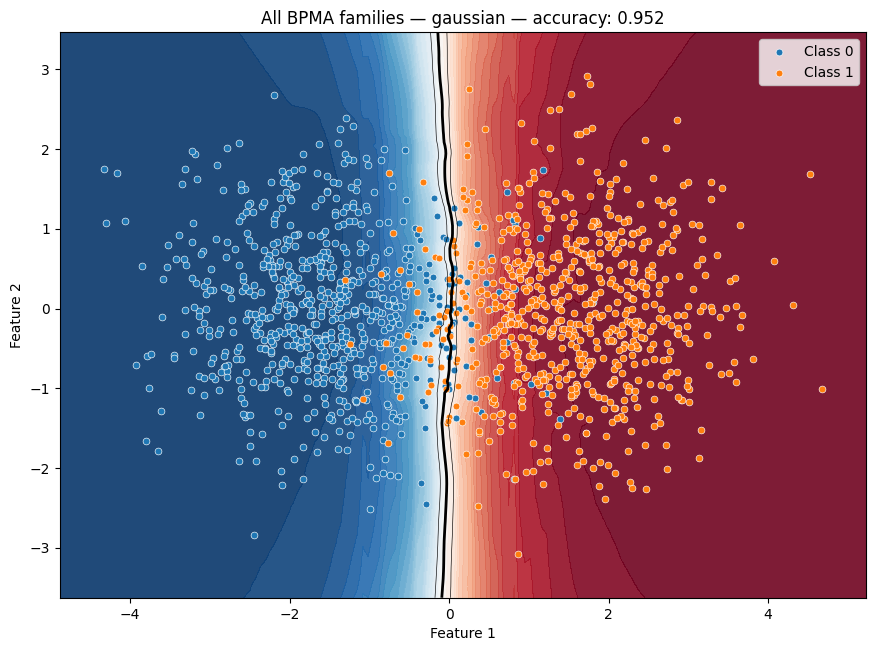

dataset: blobs
runtime: 51.37s
test accuracy: 0.832
test errors: 101/600
test error: 0.168; Bayes error (density estimate): 0.155; model/Bayes error ratio: 1.08
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.326, knn=0.121, linear_mixture=0.213, mlp=0.154, random_forest=0.186
  gaussian-mixture covariance structure posterior shares: full=0.378, isotropic=0.358, diagonal=0.264
  gaussian-mixture component-count posterior shares (top 12): 1=0.253, 5=0.098, 7=0.087, 14=0.084, 8=0.065, 9=0.063, 6=0.061, 4=0.057, 2=0.033, 3=0.033, 13=0.031, 20=0.030, other=0.104
  knn k posterior shares (top 12): 11=0.136, 5=0.131, 157=0.103, 198=0.097, 260=0.088, 129=0.078, 391=0.061, 440=0.056, 74=0.044, 470=0.035, 179=0.035, 611=0.034, other=0.101
  linear-mixture expert-count posterior shares: 1=0.330, 2=0.280, 3=0.203, 4=0.104, 5=0.083
  mlp architecture posterior shares: (16,)=0.498, (32,)=0.261, (32, 16)=0.158, (64,)=0.082
  mlp activation posterior shares: relu=0.7

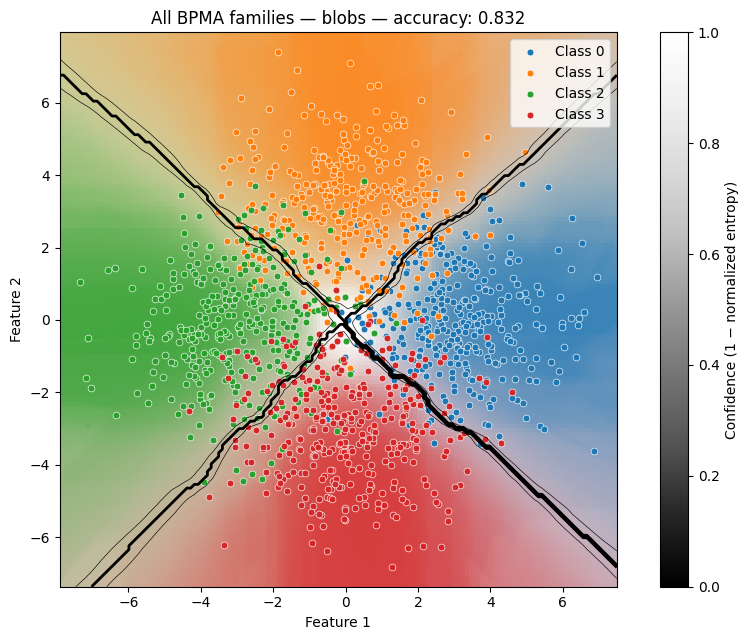

dataset: anisotropic_blobs
runtime: 33.55s
test accuracy: 0.840
test errors: 96/600
test error: 0.160; Bayes error (density estimate): 0.155; model/Bayes error ratio: 1.03
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.292, knn=0.097, linear_mixture=0.215, mlp=0.195, random_forest=0.201
  gaussian-mixture covariance structure posterior shares: isotropic=0.389, full=0.348, diagonal=0.263
  gaussian-mixture component-count posterior shares (top 12): 1=0.174, 5=0.112, 7=0.098, 8=0.079, 3=0.071, 6=0.071, 4=0.068, 14=0.067, 2=0.055, 13=0.037, 9=0.037, 10=0.037, other=0.093
  knn k posterior shares (top 12): 11=0.185, 157=0.109, 198=0.105, 260=0.091, 129=0.083, 391=0.064, 440=0.059, 74=0.049, 179=0.042, 150=0.042, 470=0.041, 611=0.041, other=0.090
  linear-mixture expert-count posterior shares: 2=0.290, 3=0.256, 1=0.252, 4=0.115, 5=0.087
  mlp architecture posterior shares: (16,)=0.475, (32,)=0.234, (32, 16)=0.211, (64,)=0.080
  mlp activation posterior sha

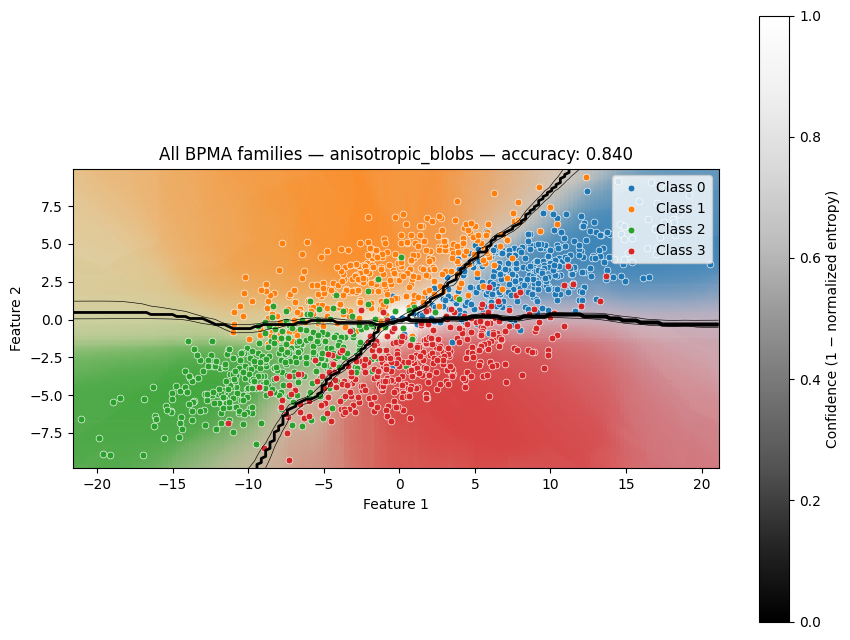

dataset: classification
runtime: 32.86s
test accuracy: 0.883
test errors: 70/600
test error: 0.117; Bayes error: unavailable
estimators used: 100
converged: False
family posterior shares: gaussian_mixture=0.371, knn=0.153, linear_mixture=0.126, mlp=0.110, random_forest=0.239
  gaussian-mixture covariance structure posterior shares: full=0.546, isotropic=0.269, diagonal=0.185
  gaussian-mixture component-count posterior shares (top 12): 14=0.129, 7=0.111, 1=0.109, 9=0.094, 5=0.088, 8=0.080, 4=0.061, 6=0.049, 24=0.046, 19=0.042, 20=0.040, 15=0.040, other=0.111
  knn k posterior shares (top 12): 11=0.135, 26=0.126, 5=0.085, 37=0.073, 198=0.063, 157=0.059, 260=0.054, 129=0.045, 391=0.043, 440=0.040, 179=0.030, 150=0.029, other=0.218
  linear-mixture expert-count posterior shares: 2=0.382, 4=0.194, 1=0.183, 5=0.136, 3=0.105
  mlp architecture posterior shares: (16,)=0.670, (32, 16)=0.248, (32,)=0.082
  mlp activation posterior shares: relu=0.822, logistic=0.178
  random-forest tree-count po

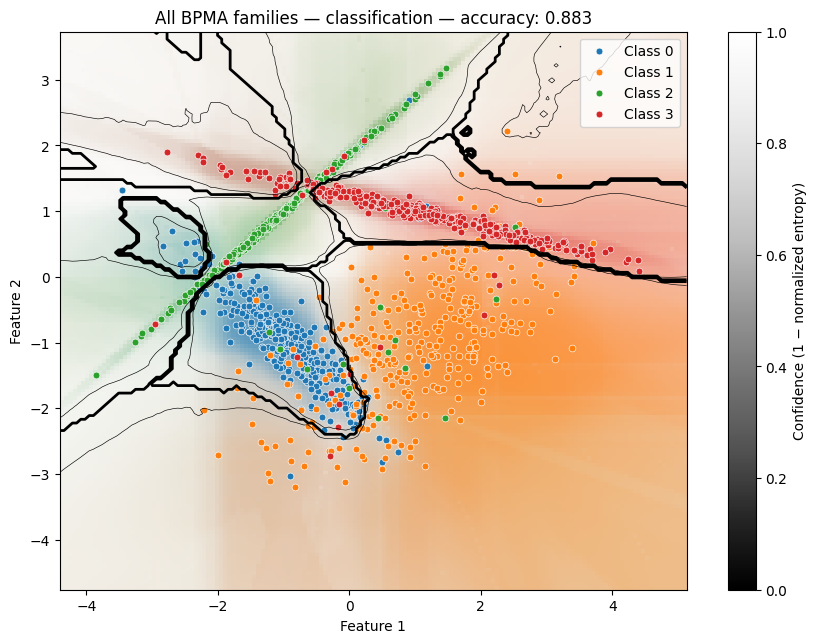

In [4]:
ADAPTIVE_MODEL_PARAMETERS = {
    **MODEL_PARAMETERS,
    "max_estimators": ESTIMATORS_PER_FAMILY * len(FAMILY_ADAPTERS),
    "adaptive_importance_sampling": True,
    "round_size": ADAPTIVE_ROUND_SIZE_PER_FAMILY * len(FAMILY_ADAPTERS),
}

for result in run_and_report(
    DATASETS,
    dataset_parameters=DATA_PARAMETERS,
    split_parameters=SPLIT_PARAMETERS,
    model_parameters=ADAPTIVE_MODEL_PARAMETERS,
):
    figure = plot_probability_heatmap(
        result.model,
        result.X,
        result.y,
        X_train=result.X_train,
        y_train=result.y_train,
        title=f"All BPMA families — {result.dataset} — accuracy: {result.test_accuracy:.3f}",
        **PLOT_PARAMETERS,
    )
    display(figure)
    plt.close(figure)